First Five Rows


,Name,Branch,StudyHours,Attendance,Marks
0,Krishna Sharma,Civil,7,81,60.88
1,Ananya Patel,ECE,4,70,50.33
2,Priya Verma,ECE,8,75,71.53
3,Krishna Mishra,ECE,5,92,55.68
4,Aditya Kapoor,ECE,7,68,71.39



Information
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        200 non-null    str    
 1   Branch      200 non-null    str    
 2   StudyHours  200 non-null    int64  
 3   Attendance  200 non-null    int64  
 4   Marks       200 non-null    float64
dtypes: float64(1), int64(2), str(2)
memory usage: 7.9 KB

Statistical Summary


,StudyHours,Attendance,Marks
count,200.000000,200.000000,200.000000
mean,5.560000,81.250000,61.993500
std,2.899731,11.778419,19.438103
min,1.000000,60.000000,17.150000
25%,3.000000,71.750000,48.157500
50%,6.000000,82.000000,62.350000
75%,8.000000,92.000000,77.935000
max,10.000000,100.000000,100.000000



Missing Values
Name          0
Branch        0
StudyHours    0
Attendance    0
Marks         0
dtype: int64


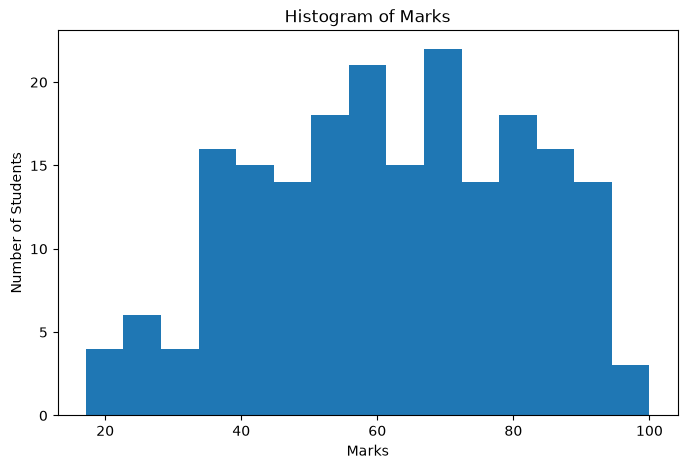

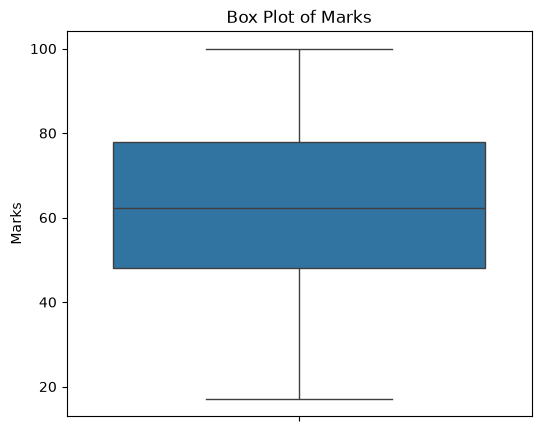

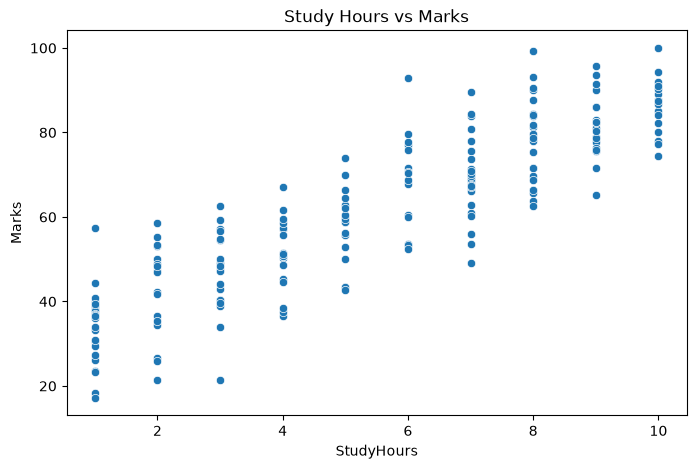

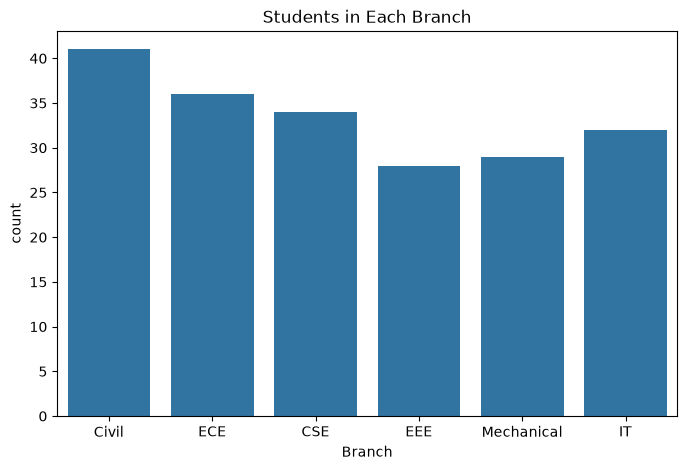

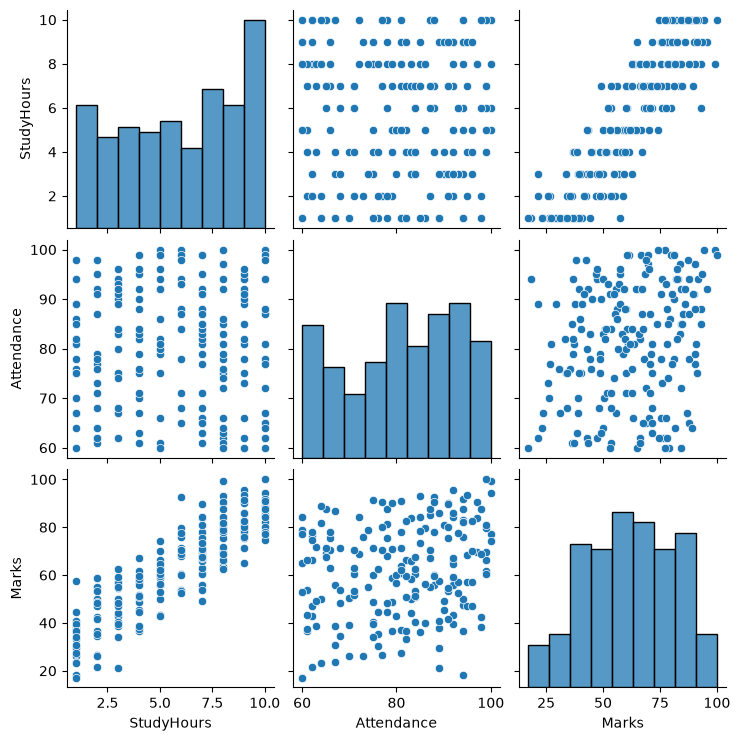

Correlation Matrix


,StudyHours,Attendance,Marks
StudyHours,1.000000,0.009858,0.880830
Attendance,0.009858,1.000000,0.216943
Marks,0.880830,0.216943,1.000000


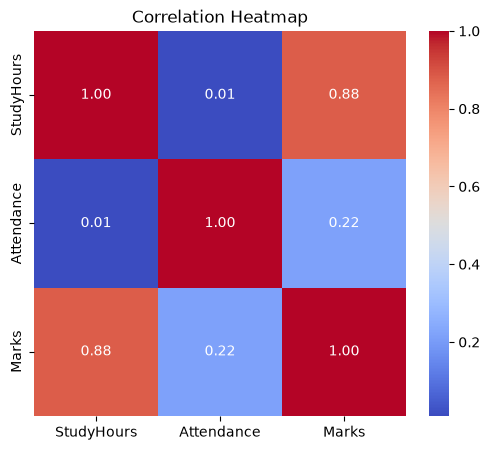

Average Marks by Branch


Branch
Civil         65.122195
ECE           64.843056
IT            61.650937
CSE           60.895588
Mechanical    60.806897
EEE           56.702143
Name: Marks, dtype: float64

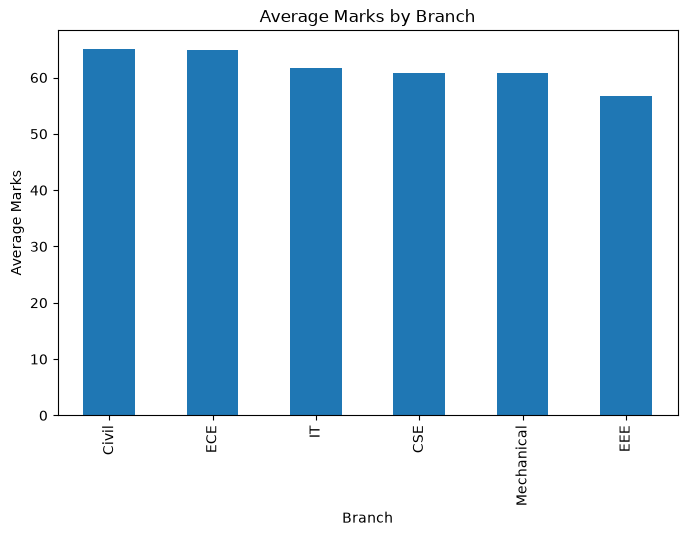

In [1]:
# ==========================================
# Student Dataset Generation & EDA
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

# -----------------------------
# Generate Dataset
# -----------------------------

np.random.seed(42)
random.seed(42)

first_names = [
    "Aarav","Vivaan","Aditya","Krishna","Aryan","Rohan","Rahul",
    "Priya","Ananya","Sneha","Neha","Ishita","Karan","Arjun",
    "Sakshi","Aditi","Mohit","Nikhil","Riya","Simran"
]

last_names = [
    "Sharma","Singh","Verma","Patel","Gupta","Kumar",
    "Yadav","Joshi","Mishra","Kapoor"
]

branches = [
    "CSE",
    "IT",
    "ECE",
    "EEE",
    "Mechanical",
    "Civil"
]

names = [
    random.choice(first_names) + " " + random.choice(last_names)
    for _ in range(200)
]

study_hours = np.random.randint(1, 11, 200)
attendance = np.random.randint(60, 101, 200)

marks = (
    study_hours * 6
    + attendance * 0.35
    + np.random.normal(0, 8, 200)
)

marks = np.clip(marks, 0, 100).round(2)

df = pd.DataFrame({
    "Name": names,
    "Branch": np.random.choice(branches, 200),
    "StudyHours": study_hours,
    "Attendance": attendance,
    "Marks": marks
})

# -----------------------------
# EDA
# -----------------------------

print("First Five Rows")
display(df.head())

print("\nInformation")
df.info()

print("\nStatistical Summary")
display(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

# -----------------------------
# Histogram
# -----------------------------

plt.figure(figsize=(8,5))
plt.hist(df["Marks"], bins=15)
plt.title("Histogram of Marks")
plt.xlabel("Marks")
plt.ylabel("Number of Students")
plt.show()

# -----------------------------
# Box Plot
# -----------------------------

plt.figure(figsize=(6,5))
sns.boxplot(y=df["Marks"])
plt.title("Box Plot of Marks")
plt.show()

# -----------------------------
# Scatter Plot
# -----------------------------

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="StudyHours", y="Marks")
plt.title("Study Hours vs Marks")
plt.show()

# -----------------------------
# Count Plot
# -----------------------------

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Branch")
plt.title("Students in Each Branch")
plt.show()

# -----------------------------
# Pair Plot
# -----------------------------

sns.pairplot(df[["StudyHours","Attendance","Marks"]])
plt.show()

# -----------------------------
# Correlation Matrix
# -----------------------------

corr = df[["StudyHours","Attendance","Marks"]].corr()

print("Correlation Matrix")
display(corr)

# -----------------------------
# Heatmap
# -----------------------------

plt.figure(figsize=(6,5))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------
# Average Marks by Branch
# -----------------------------

avg_marks = df.groupby("Branch")["Marks"].mean().sort_values(ascending=False)

print("Average Marks by Branch")
display(avg_marks)

plt.figure(figsize=(8,5))
avg_marks.plot(kind="bar")
plt.title("Average Marks by Branch")
plt.ylabel("Average Marks")
plt.show()